# Light Field Microscope (LFM) Simulation

This notebook provides an interactive, educational exploration of how light field microscopy works.

**What you'll learn:**
- How a microlens array encodes 3D information into a 2D sensor image
- How Richardson-Lucy deconvolution reconstructs 3D volumes
- How optical parameters (NA, magnification, microlens pitch) affect image quality
- What happens when the microlens array is misaligned

**How it works:** We use the [pyolaf](https://github.com/pvjosue/pyolaf) library's **wave-optics forward model** (Huygens-Fresnel diffraction + Rayleigh-Sommerfeld propagation through the microlens array). This is more accurate than geometric ray tracing at microlens scales where diffraction matters — no separate ray tracing software needed.

**Performance notes:**
- `'fast'` quality: ~30s setup, good for quick exploration
- `'medium'` quality: ~2-5 min setup, better detail for final comparisons
- `'high'` quality: ~10+ min setup, publication-quality results

The expensive step is computing the PSF operators (H, Ht) — once computed, you can forward-project and reconstruct many different scenes quickly.

In [1]:
# Imports and setup
import sys
import os
import importlib
import numpy as np
import matplotlib.pyplot as plt

# Auto-reload modules when they change
%matplotlib inline
%load_ext autoreload
%autoreload 2

# Import simulation module
sys.path.insert(0, os.path.dirname(os.path.abspath('')))
sys.path.insert(0, os.path.abspath(''))
from lfm_sim import (
    LFMSimConfig, setup_simulation, forward_project, reconstruct,
    simulate_and_reconstruct, get_depths_um,
    create_point_sources, create_fluorescent_beads, create_planar_layer,
    create_tilted_plane, create_resolution_target,
    apply_misalignment,
    plot_light_field, plot_volume_slices, compare_side_by_side,
    plot_lf_zoomed, QUALITY_PRESETS,
)

print('Imports OK')
print(f'Quality presets: {list(QUALITY_PRESETS.keys())}')

C:\ProgramData\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,


Imports OK
Quality presets: ['fast', 'medium', 'high']


---
## Demo 1: Hello LFM — Your First Light Field Image

We start with the simplest possible scene: a single **point source** at the center of the volume. This shows:

1. **The raw light field image** — notice the repeating pattern of bright spots. Each spot is the image of the point source as seen through one microlens. The pattern encodes angular (directional) information about the light.

2. **The reconstructed volume** — Richardson-Lucy deconvolution inverts the forward model to recover the 3D position of the point source. The reconstruction at the correct depth should show a tight spot.

### Key concept: The microlens array
In a conventional microscope, the sensor captures a 2D image. In LFM, a **microlens array** (MLA) is placed at the intermediate image plane. Each microlens acts as a tiny lens that re-images the specimen onto a small patch of the sensor. Different pixels behind the same microlens see the specimen from slightly different angles — this angular sampling enables 3D reconstruction from a single shot.

In [2]:
# Set up the simulation with default optics
# Change quality to 'medium' or 'high' for better results (but slower)
config = LFMSimConfig(quality='fast')
config.summary()

print("\nBuilding forward model (this is the slow step)...")
sim = setup_simulation(config)

=== LFM Configuration ===
  Objective: 10.0x / NA 0.3
  f_obj = 20000 um, f_tube = 200000 um
  Microlens: pitch=125.0 um, f=1875.0 um
  Sensor pixel: 6.5 um (19.2 px/lenslet)
  Wavelength: 0.525 um, n=1.0
  Depth range: [-300, 300] um, step=150.0 um
  Quality: 'fast'

Building forward model (this is the slow step)...
Setting up camera parameters...
Computing geometry (simulation mode)...
[19 19] reg [6.578947368421052, 6.578947368421052] 56.25 [19 19]
[3 3] reg [  4.16666667   4.16666667 150.        ] 6.249999999999999 [3 3]
Super resolution factor of: [3 3]
Pix size: [6.578947368421052, 6.578947368421052]
Vox size: [4.166666666666666, 4.166666666666666, 150.0]
  Geometry ready in 0.2s
Computing PSF operators (this may take a while)...
Size of PSF radius ~= 10.0 [microlens pitch]
Size of PSF IMAGE = 381X381 [Pixels]
Computing PSF for main objective:
...
PSF: 1/5 in 2.81s
PSF: 2/5 in 2.79s
PSF: 3/5 in 2.80s
PSF: 4/5 already computed for depth -150.0
PSF: 5/5 already computed for depth -

 forward patterns: 100%|████████████████| 5/5 [00:00<00:00,  7.69it/s]
C:\ProgramData\anaconda3\Lib\site-packages\scipy\sparse\_compressed.py:291: SparseEfficiencyWarning: Comparing a sparse matrix with a scalar greater than zero using < is inefficient, try using >= instead.
  warn(bad_scalar_msg, SparseEfficiencyWarning)
C:\ProgramData\anaconda3\Lib\site-packages\scipy\sparse\_index.py:146: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


Computing backward patterns for single focus array


backward patterns: 100%|██████████████| 10/10 [00:06<00:00,  1.55it/s]

  PSF operators ready in 15.9s
  Total setup time: 16.1s
  Volume shape: (49, 49, 5) (ny, nx, n_depths)
  Image shape: (301, 301)
  Depth planes: 5 from -300 to 300 um


In [3]:
# Create a single point source at the center of the volume
volume = create_point_sources(sim['volumeSize'], positions=[(0.5, 0.5, 0.5)])

print(f"Volume shape: {volume.shape}  (ny, nx, n_depths)")
print(f"Point source at center voxel")

# Forward project: 3D volume → 2D light field image
print("\nForward projecting (3D → 2D)...")
lf_image = forward_project(volume, sim)
print(f"Light field image shape: {lf_image.shape}")
print(f"  Max intensity: {lf_image.max():.4f}")

Volume shape: (49, 49, 5)  (ny, nx, n_depths)
Point source at center voxel

Forward projecting (3D → 2D)...


forward : 100%|█████████████████████████| 5/5 [00:00<00:00,  8.27it/s]


Light field image shape: (301, 301)
  Max intensity: 0.0092


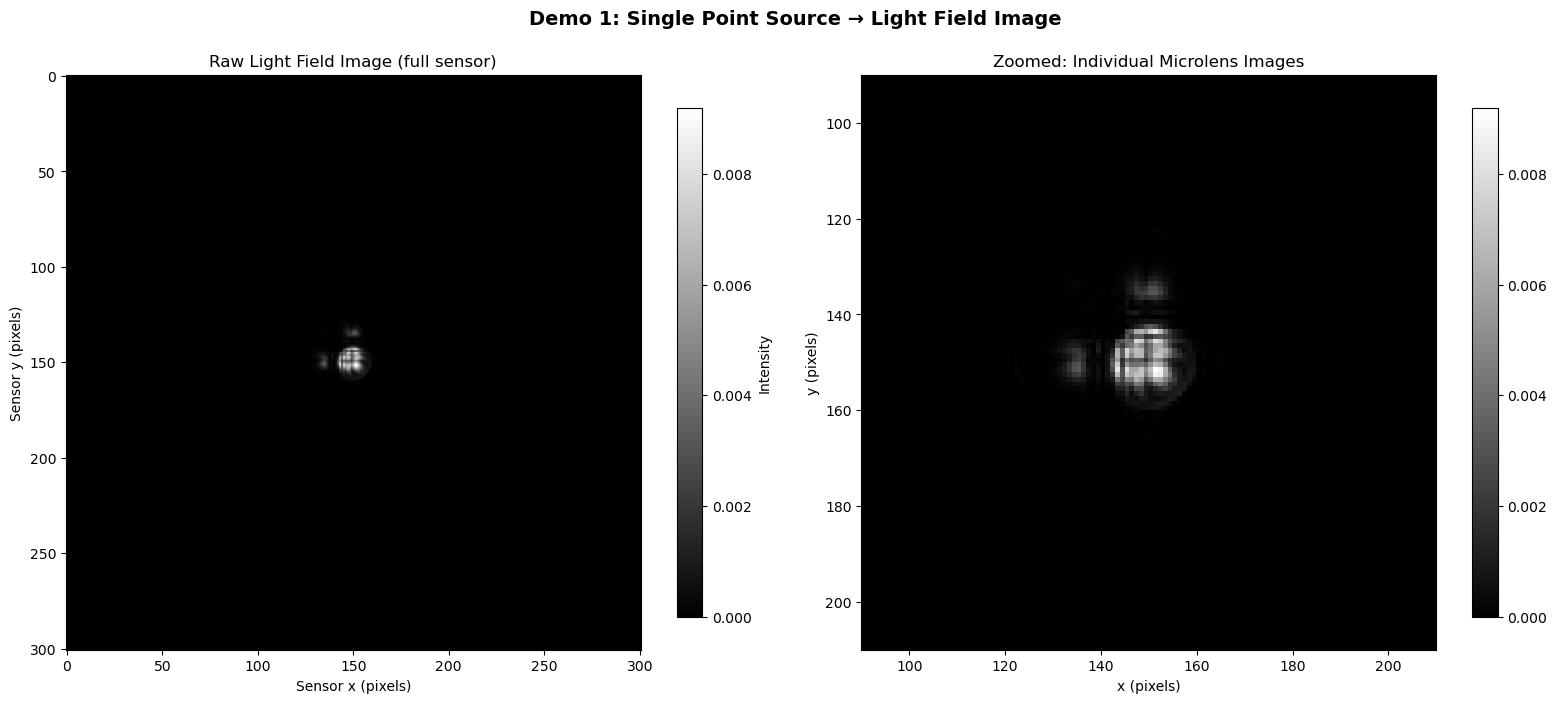

Each bright spot = the point source imaged through one microlens.
The pattern of spots encodes angular information for 3D reconstruction.


In [4]:
# Visualize the light field image
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Full light field image
plot_light_field(lf_image, title="Raw Light Field Image (full sensor)", ax=axes[0])

# Zoomed in to see individual microlens images
plot_lf_zoomed(lf_image, radius=60,
               title="Zoomed: Individual Microlens Images", ax=axes[1])

fig.suptitle("Demo 1: Single Point Source → Light Field Image",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Each bright spot = the point source imaged through one microlens.")
print("The pattern of spots encodes angular information for 3D reconstruction.")

Precomputing normalization projections...


backward: 100%|█████████████████████████| 5/5 [00:00<00:00, 15.60it/s]


  Iteration 1/1...


backward: 100%|█████████████████████████| 5/5 [00:00<00:00, 10.34it/s]

  Reconstruction done in 0.6s (1 iterations)


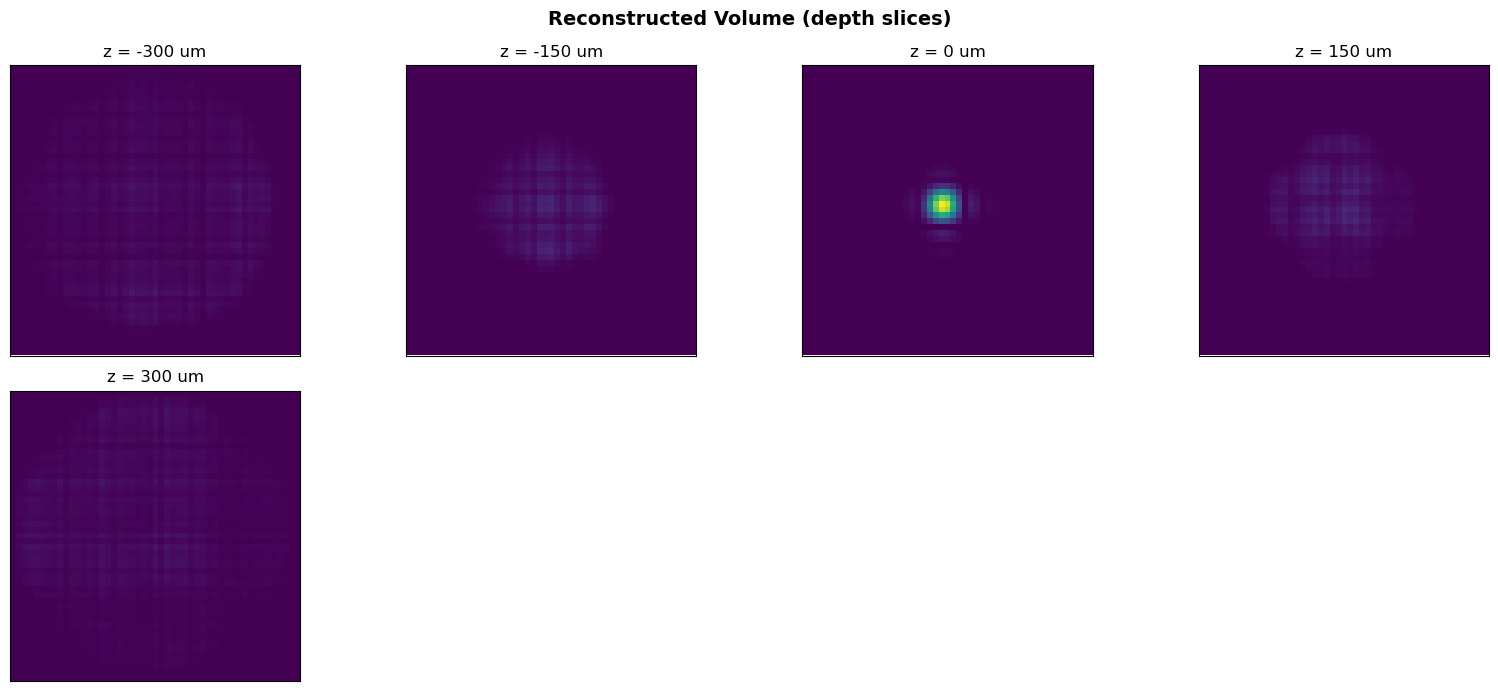

The point source should appear brightest at the center depth plane.
Some spread to adjacent depths is normal (axial PSF).


In [5]:
# Reconstruct the 3D volume from the light field image
recon = reconstruct(lf_image, sim)

# Show depth slices
depths = get_depths_um(sim)
plot_volume_slices(recon, depths_um=depths, title="Reconstructed Volume (depth slices)")
plt.show()

print("The point source should appear brightest at the center depth plane.")
print("Some spread to adjacent depths is normal (axial PSF).")

---
## Demo 2: Depth Sectioning — 3D from a Single Shot

Here we place **three point sources at different depths** to demonstrate how LFM captures 3D information in one exposure.

### Key concept: Depth encoding
Objects at different depths produce different patterns on the sensor. An in-focus object (at the native focal plane of the MLA) produces a tight spot under each microlens. An out-of-focus object produces a broader, more diffuse pattern. The deconvolution algorithm uses these differences to assign each part of the image to the correct depth.

Forward projecting...


forward : 100%|█████████████████████████| 5/5 [00:00<00:00,  8.63it/s]


Reconstructing...
Precomputing normalization projections...


backward: 100%|█████████████████████████| 5/5 [00:00<00:00, 17.86it/s]


  Iteration 1/1...


backward: 100%|█████████████████████████| 5/5 [00:00<00:00,  9.67it/s]


  Reconstruction done in 0.6s (1 iterations)


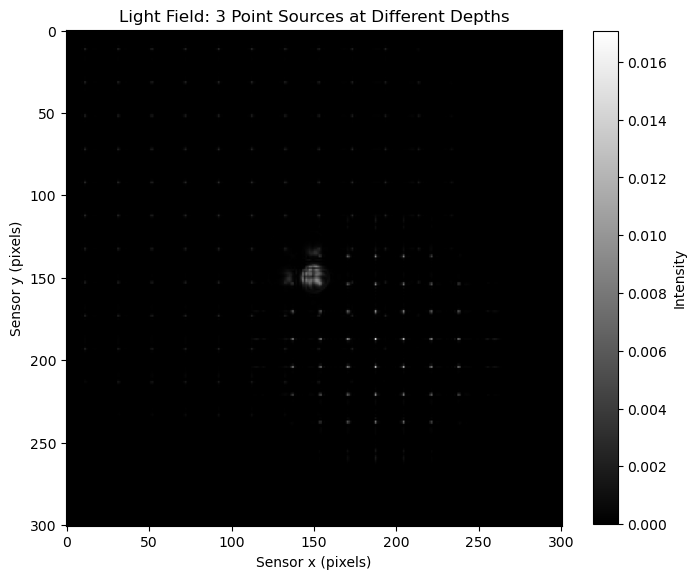

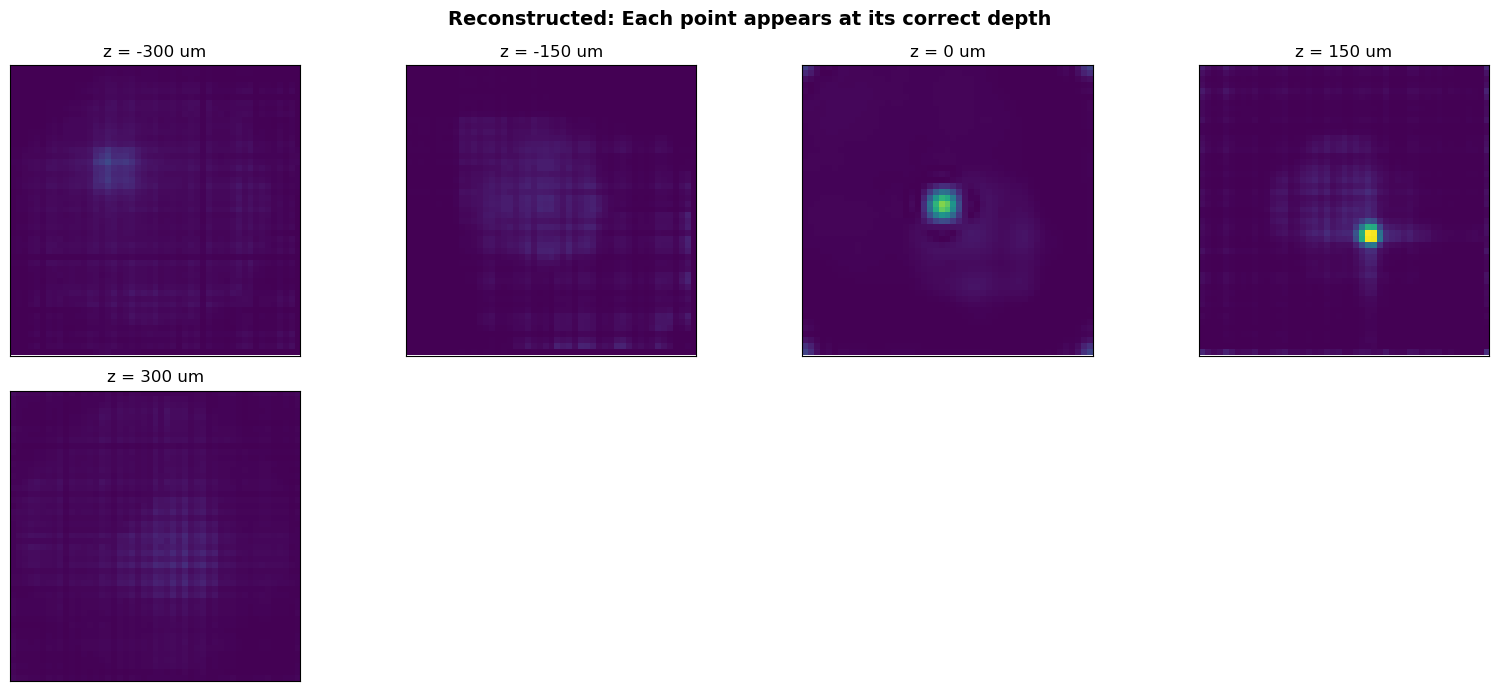

Each point source should appear brightest at its assigned depth plane.
This demonstrates LFM's ability to resolve 3D structure from a single 2D capture.


In [6]:
# Three point sources at different depths and lateral positions
# (y_frac, x_frac, depth_frac) — each in [0, 1]
positions = [
    (0.35, 0.35, 0.15),  # Top-left, shallow
    (0.50, 0.50, 0.50),  # Center, middle
    (0.65, 0.65, 0.85),  # Bottom-right, deep
]

volume_3pts = create_point_sources(sim['volumeSize'], positions)

# Simulate and reconstruct
result = simulate_and_reconstruct(volume_3pts, sim)

# Show the light field
fig = plot_light_field(result['lf_image'],
                       title="Light Field: 3 Point Sources at Different Depths")
plt.show()

# Show reconstructed slices
depths = get_depths_um(sim)
fig = plot_volume_slices(result['reconstructed'], depths_um=depths,
                         title="Reconstructed: Each point appears at its correct depth")
plt.show()

print("Each point source should appear brightest at its assigned depth plane.")
print("This demonstrates LFM's ability to resolve 3D structure from a single 2D capture.")

---
## Demo 3: Resolution vs. Numerical Aperture (NA)

The objective's **numerical aperture** is one of the most important parameters in any microscope. Higher NA means:
- Better lateral resolution (smaller PSF)
- Shallower depth of field
- More light collection

Here we simulate the same scene with three different NA values to see the effect.

### Key concept: The NA trade-off
In LFM, NA affects both the objective's diffraction limit and how the light is distributed across the microlens array. Higher NA collects more angular information, improving both lateral and axial resolution — but the computation is more demanding.

In [7]:
# Compare NA = 0.1, 0.3, 0.5
# NOTE: Each setup_simulation() call recomputes PSF operators — this takes time!
na_values = [0.1, 0.3, 0.5]
na_results = {}

for na in na_values:
    print(f"\n--- NA = {na} ---")
    cfg = LFMSimConfig(NA=na, quality='fast')
    s = setup_simulation(cfg, verbose=True)
    
    # Same point source at center
    vol = create_point_sources(s['volumeSize'], [(0.5, 0.5, 0.5)])
    res = simulate_and_reconstruct(vol, s, verbose=False)
    na_results[na] = {'sim': s, 'result': res}


--- NA = 0.1 ---
Setting up camera parameters...
Computing geometry (simulation mode)...
[19 19] reg [6.578947368421052, 6.578947368421052] 18.75 [19 19]
[3 3] reg [  4.16666667   4.16666667 150.        ] 6.249999999999999 [3 3]
Super resolution factor of: [3 3]
Pix size: [6.578947368421052, 6.578947368421052]
Vox size: [4.166666666666666, 4.166666666666666, 150.0]
  Geometry ready in 0.5s
Computing PSF operators (this may take a while)...
Size of PSF radius ~= 5.0 [microlens pitch]
Size of PSF IMAGE = 191X191 [Pixels]
Computing PSF for main objective:
...
PSF: 1/5 in 0.11s
PSF: 2/5 in 0.07s
PSF: 3/5 in 0.09s
PSF: 4/5 already computed for depth -150.0
PSF: 5/5 already computed for depth -300.0
...
Computing forward patterns for single focus array


 forward patterns: 100%|████████████████| 5/5 [00:00<00:00, 35.53it/s]


Computing backward patterns for single focus array


backward patterns: 100%|██████████████| 10/10 [00:01<00:00,  5.86it/s]


  PSF operators ready in 2.2s
  Total setup time: 2.8s
  Volume shape: (49, 49, 5) (ny, nx, n_depths)
  Image shape: (301, 301)
  Depth planes: 5 from -300 to 300 um


...

 forward patterns: 100%|████████████████| 5/5 [00:01<00:00,  4.18it/s]


Computing backward patterns for single focus array


backward patterns: 100%|██████████████| 10/10 [00:10<00:00,  1.08s/it]


  PSF operators ready in 57.4s
  Total setup time: 57.4s
  Volume shape: (49, 49, 5) (ny, nx, n_depths)
  Image shape: (301, 301)
  Depth planes: 5 from -300 to 300 um


backward: 100%|█████████████████████████| 5/5 [00:00<00:00,  8.32it/s]


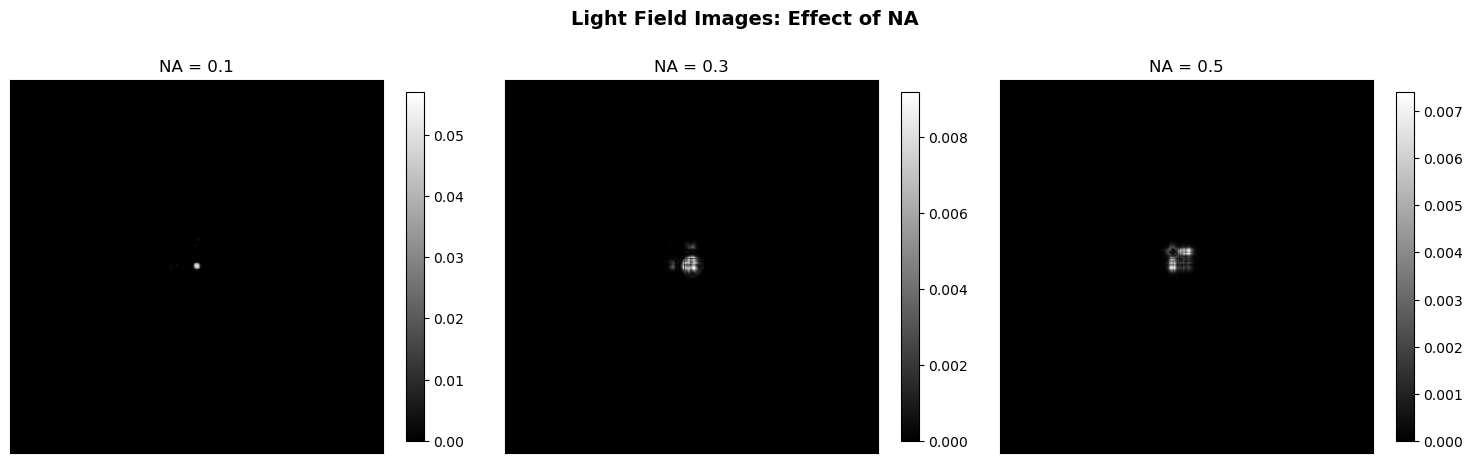

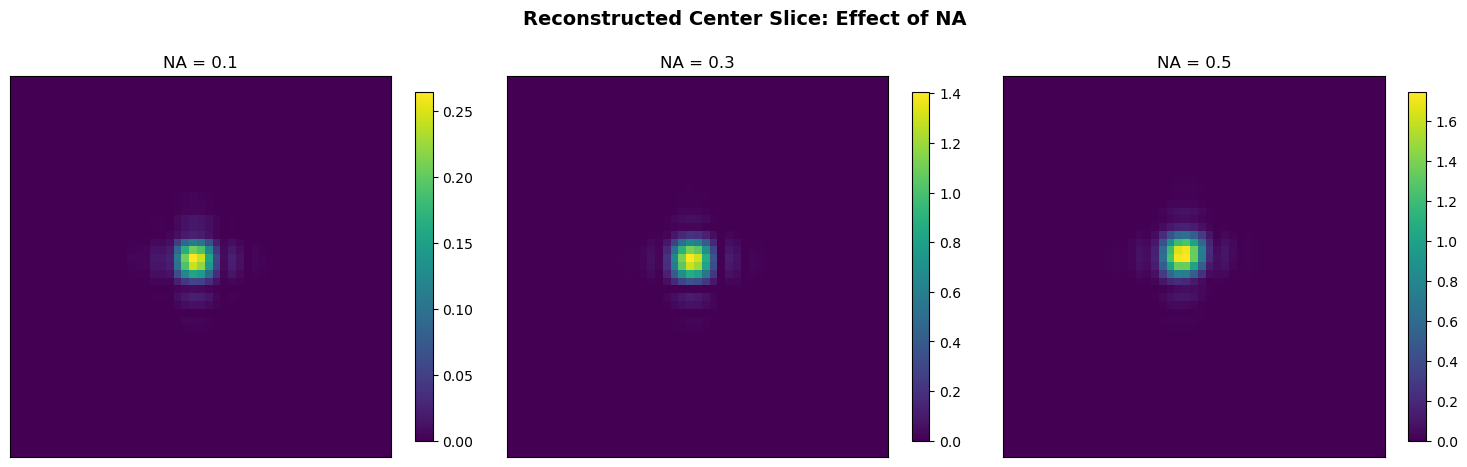

Higher NA → sharper PSF (tighter point), but different light distribution
across the microlens array.


In [8]:
# Compare light field images
lf_images = [na_results[na]['result']['lf_image'] for na in na_values]
labels = [f'NA = {na}' for na in na_values]
fig = compare_side_by_side(lf_images, labels,
                           suptitle="Light Field Images: Effect of NA")
plt.show()

# Compare center depth slice of reconstruction
recon_slices = []
for na in na_values:
    recon = na_results[na]['result']['reconstructed']
    mid_z = recon.shape[2] // 2
    recon_slices.append(recon[:, :, mid_z])

fig = compare_side_by_side(recon_slices, labels, cmap='viridis',
                           suptitle="Reconstructed Center Slice: Effect of NA")
plt.show()

print("Higher NA → sharper PSF (tighter point), but different light distribution")
print("across the microlens array.")

---
## Demo 4: Microlens Pitch Trade-off

The microlens **pitch** (spacing between lenslets) controls a fundamental trade-off in LFM:

- **Smaller pitch** → more microlenses across the sensor → better **spatial** resolution (more sampling points in x,y) but fewer pixels behind each lens → worse **angular** resolution (fewer viewing directions)
- **Larger pitch** → fewer microlenses → worse spatial resolution but more pixels per lens → better angular resolution (better depth discrimination)

This is the core design tension in LFM: you split a fixed number of sensor pixels between spatial and angular sampling.

In [9]:
# Compare microlens pitches
pitch_values = [75, 125, 200]  # um
pitch_results = {}

for pitch in pitch_values:
    print(f"\n--- Lens pitch = {pitch} um ---")
    cfg = LFMSimConfig(lens_pitch=pitch, quality='fast')
    px_per_lens = pitch / cfg.pixel_pitch
    print(f"  Pixels per lenslet: {px_per_lens:.1f}")
    s = setup_simulation(cfg, verbose=True)
    
    vol = create_point_sources(s['volumeSize'], [(0.5, 0.5, 0.5)])
    res = simulate_and_reconstruct(vol, s, verbose=False)
    pitch_results[pitch] = {'sim': s, 'result': res}


--- Lens pitch = 75 um ---
  Pixels per lenslet: 11.5
Setting up camera parameters...
Computing geometry (simulation mode)...
[19 19] reg [3.9473684210526314, 3.9473684210526314] 56.25 [19 19]
[3 3] reg [  2.5   2.5 150. ] 3.75 [3 3]
Super resolution factor of: [3 3]
Pix size: [3.9473684210526314, 3.9473684210526314]
Vox size: [2.5, 2.5, 150.0]
  Geometry ready in 0.0s
Computing PSF operators (this may take a while)...
Size of PSF radius ~= 14.0 [microlens pitch]
Size of PSF IMAGE = 533X533 [Pixels]
Computing PSF for main objective:
...
PSF: 1/5 in 7.34s
PSF: 2/5 in 7.31s
PSF: 3/5 in 7.32s
PSF: 4/5 already computed for depth -150.0
PSF: 5/5 already computed for depth -300.0
...
Computing forward patterns for single focus array


 forward patterns: 100%|████████████████| 5/5 [00:01<00:00,  4.27it/s]


Computing backward patterns for single focus array


backward patterns: 100%|██████████████| 10/10 [00:12<00:00,  1.25s/it]


  PSF operators ready in 36.4s
  Total setup time: 36.4s
  Volume shape: (49, 49, 5) (ny, nx, n_depths)
  Image shape: (301, 301)
  Depth planes: 5 from -300 to 300 um


...

 forward patterns: 100%|████████████████| 5/5 [00:00<00:00, 15.12it/s]


Computing backward patterns for single focus array


backward patterns: 100%|██████████████| 10/10 [00:02<00:00,  3.74it/s]


  PSF operators ready in 7.1s
  Total setup time: 7.5s
  Volume shape: (49, 49, 5) (ny, nx, n_depths)
  Image shape: (301, 301)
  Depth planes: 5 from -300 to 300 um


backward: 100%|█████████████████████████| 5/5 [00:00<00:00, 30.66it/s]


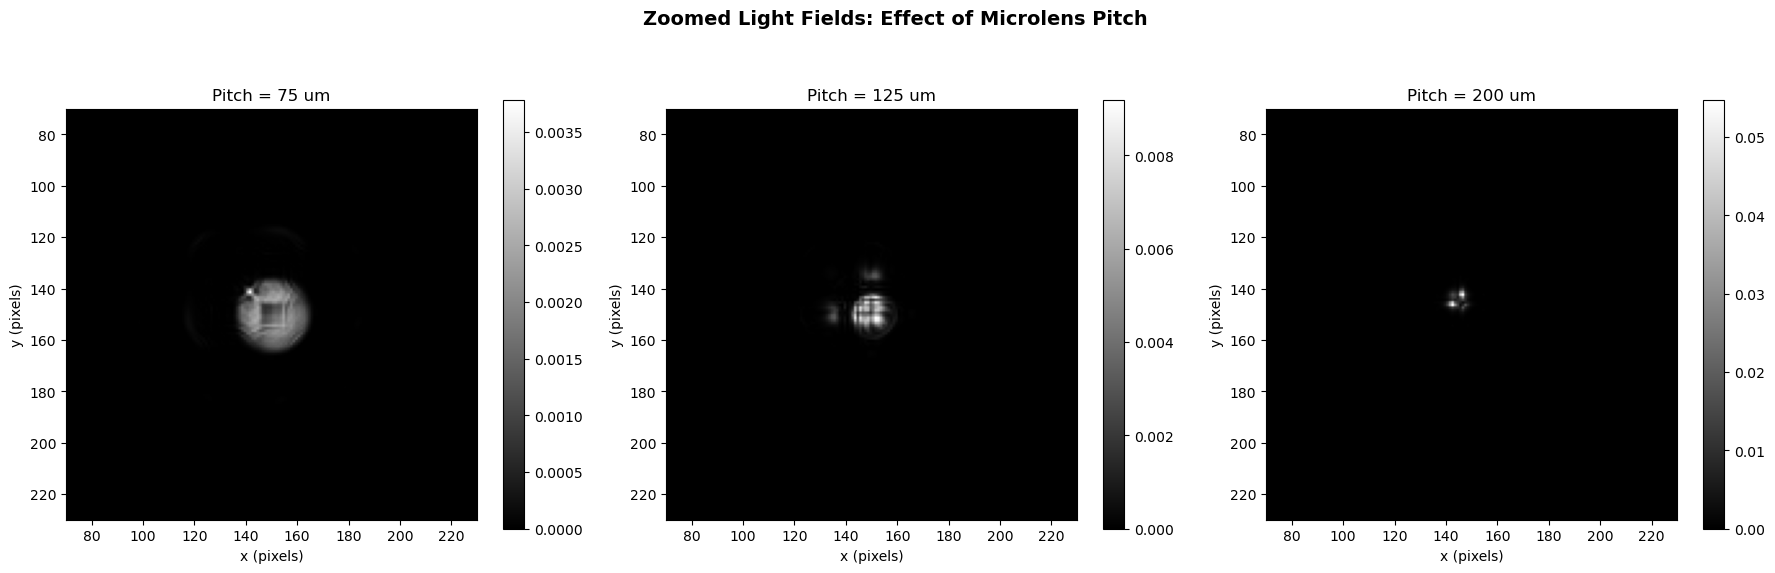

Smaller pitch → more, smaller microlens images (better spatial, worse angular)
Larger pitch → fewer, bigger microlens images (worse spatial, better angular)


In [10]:
# Compare light field images — zoom in to see microlens size differences
fig, axes = plt.subplots(1, len(pitch_values), figsize=(6*len(pitch_values), 6))
for i, pitch in enumerate(pitch_values):
    lf = pitch_results[pitch]['result']['lf_image']
    plot_lf_zoomed(lf, radius=80,
                   title=f'Pitch = {pitch} um', ax=axes[i])
fig.suptitle("Zoomed Light Fields: Effect of Microlens Pitch",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Smaller pitch → more, smaller microlens images (better spatial, worse angular)")
print("Larger pitch → fewer, bigger microlens images (worse spatial, better angular)")

---
## Demo 5: Misaligned Microlens Array

In practice, the MLA may not be perfectly aligned with the sensor. This demo shows what happens when the MLA is:

1. **Shifted** — translated by a few pixels
2. **Rotated** — tilted by a small angle
3. **Jittered** — random per-lenslet position errors (manufacturing defects)

### How misalignment simulation works
The forward model uses lenslet center positions to map 3D voxels to sensor pixels. We modify these positions to simulate misalignment during image formation, then reconstruct assuming ideal (known) positions — mimicking the real-world scenario where the reconstruction algorithm doesn't know about the misalignment.

**Important:** The expensive PSF operators (H, Ht) depend only on optical parameters, not on lenslet positions, so they're reused across all misalignment scenarios.

In [11]:
# Use the default config simulation we already set up
# Create a scene with multiple features to see degradation clearly
vol_beads = create_fluorescent_beads(
    sim['volumeSize'],
    bead_positions=[
        (0.3, 0.3, 0.3),
        (0.5, 0.5, 0.5),
        (0.7, 0.4, 0.7),
    ],
    bead_radius_voxels=3,
    brightness=1.0
)

# Ideal case (no misalignment)
print("--- Ideal alignment ---")
result_ideal = simulate_and_reconstruct(vol_beads, sim)

--- Ideal alignment ---
Forward projecting...


forward : 100%|█████████████████████████| 5/5 [00:00<00:00,  9.22it/s]


Reconstructing...
Precomputing normalization projections...


backward: 100%|█████████████████████████| 5/5 [00:00<00:00, 14.52it/s]


  Iteration 1/1...


backward: 100%|█████████████████████████| 5/5 [00:00<00:00, 10.32it/s]

  Reconstruction done in 0.5s (1 iterations)


In [12]:
# Shifted MLA (5 pixel offset)
print("--- Shifted MLA (dx=5, dy=3 pixels) ---")
shifted_centers = apply_misalignment(sim['LensletCenters'], 'shift',
                                     dx_px=5, dy_px=3)
result_shifted = simulate_and_reconstruct(vol_beads, sim,
                                          misaligned_centers=shifted_centers)

# Rotated MLA (5 degrees)
# Note: in 'fast' mode the grid is coarse, so small rotations (<3°) may not
# be visible. Use 'medium' quality for more realistic small-angle effects.
print("\n--- Rotated MLA (5 degrees) ---")
rotated_centers = apply_misalignment(sim['LensletCenters'], 'rotation',
                                     angle_deg=5.0)
result_rotated = simulate_and_reconstruct(vol_beads, sim,
                                          misaligned_centers=rotated_centers)

# Jittered MLA (random per-lenslet errors)
print("\n--- Jittered MLA (sigma=3 pixels) ---")
jittered_centers = apply_misalignment(sim['LensletCenters'], 'jitter',
                                      sigma_px=3.0, seed=42)
result_jittered = simulate_and_reconstruct(vol_beads, sim,
                                           misaligned_centers=jittered_centers)

--- Shifted MLA (dx=5, dy=3 pixels) ---
Forward projecting...


forward : 100%|█████████████████████████| 5/5 [00:00<00:00,  9.34it/s]


Reconstructing...
Precomputing normalization projections...


backward: 100%|█████████████████████████| 5/5 [00:00<00:00, 13.70it/s]


  Iteration 1/1...


...

Reconstructing...
Precomputing normalization projections...


backward: 100%|█████████████████████████| 5/5 [00:00<00:00, 13.08it/s]


  Iteration 1/1...


backward: 100%|█████████████████████████| 5/5 [00:00<00:00, 11.00it/s]

  Reconstruction done in 0.5s (1 iterations)


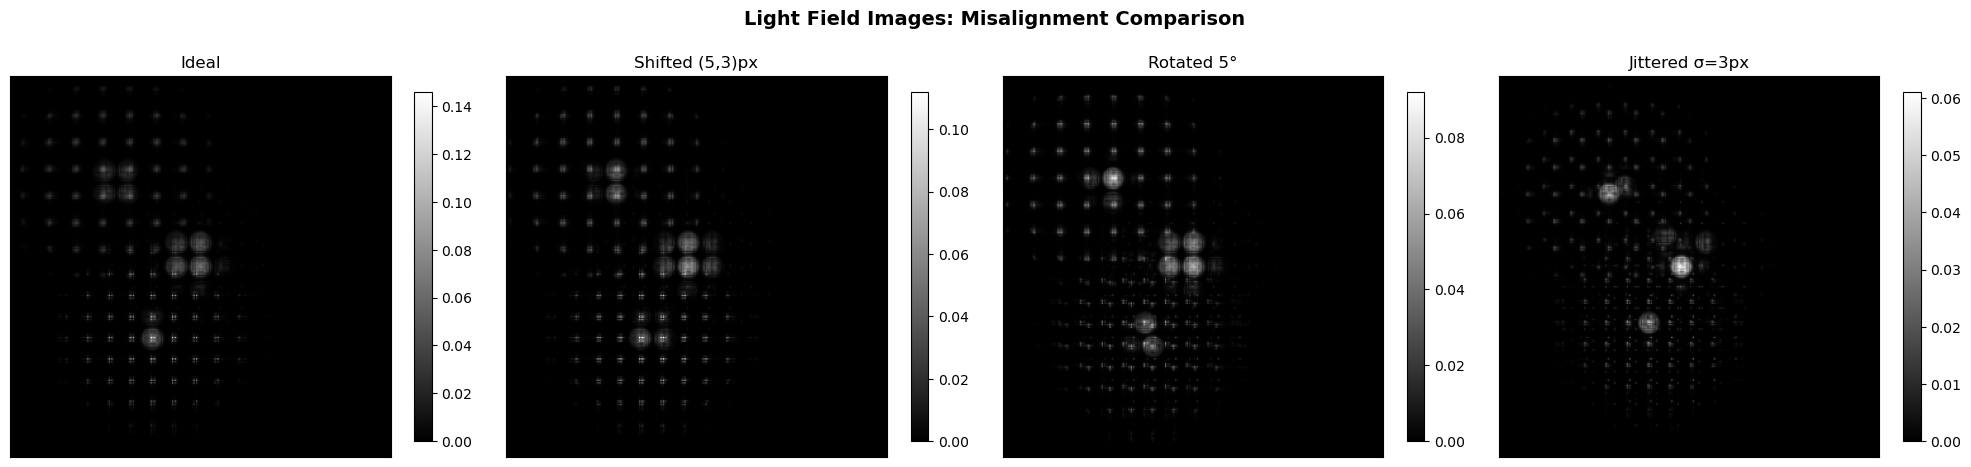

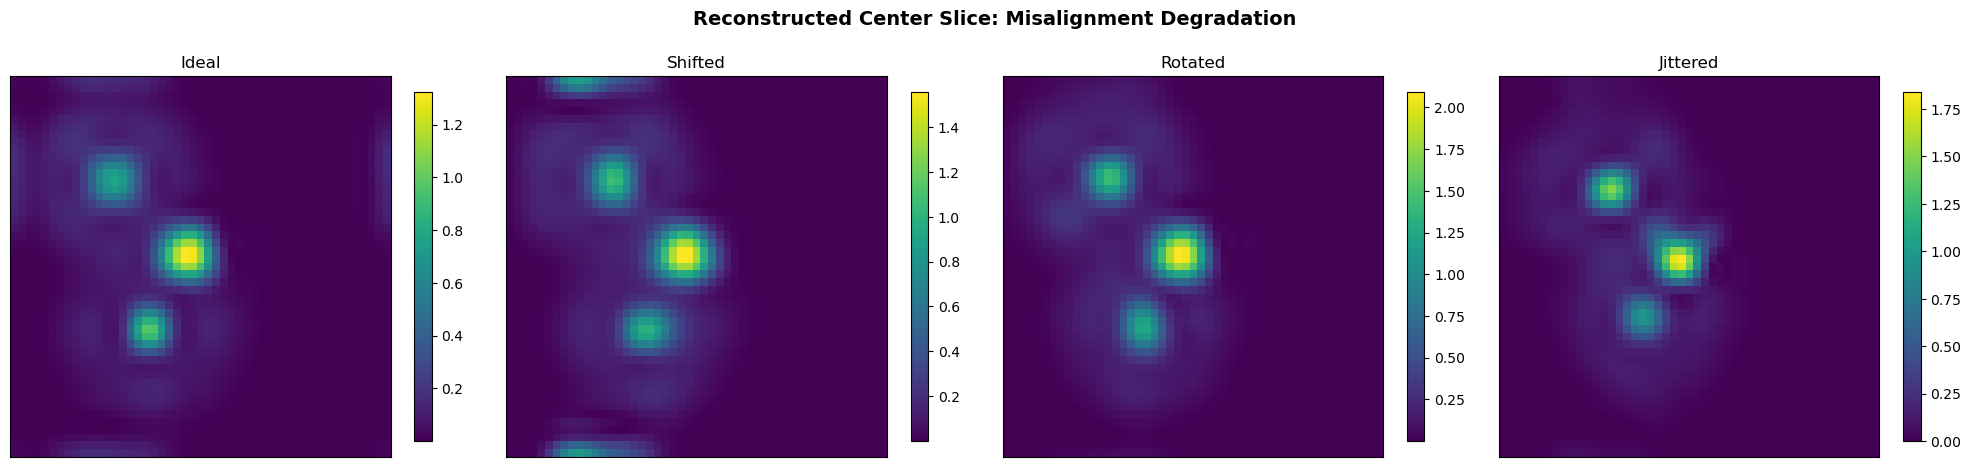

Misalignment degrades reconstruction because the algorithm assumes
ideal lenslet positions. The mismatch between actual and assumed
positions causes incorrect voxel-to-pixel mapping.


In [13]:
# Compare light field images
fig = compare_side_by_side(
    [result_ideal['lf_image'], result_shifted['lf_image'],
     result_rotated['lf_image'], result_jittered['lf_image']],
    ['Ideal', 'Shifted (5,3)px', 'Rotated 5°', 'Jittered σ=3px'],
    suptitle='Light Field Images: Misalignment Comparison',
    figsize=(20, 5)
)
plt.show()

# Compare center depth slice of reconstructions
mid_z = sim['volumeSize'][2] // 2
fig = compare_side_by_side(
    [result_ideal['reconstructed'][:, :, mid_z],
     result_shifted['reconstructed'][:, :, mid_z],
     result_rotated['reconstructed'][:, :, mid_z],
     result_jittered['reconstructed'][:, :, mid_z]],
    ['Ideal', 'Shifted', 'Rotated', 'Jittered'],
    suptitle='Reconstructed Center Slice: Misalignment Degradation',
    cmap='viridis', figsize=(20, 5)
)
plt.show()

print("Misalignment degrades reconstruction because the algorithm assumes")
print("ideal lenslet positions. The mismatch between actual and assumed")
print("positions causes incorrect voxel-to-pixel mapping.")

---
## Demo 6: Magnification

The objective **magnification** determines how the specimen is projected onto the microlens array:

- Higher magnification → the specimen image is larger at the MLA → each microlens sees a smaller part of the specimen → better spatial resolution per lenslet, but smaller field of view
- Lower magnification → the specimen image is smaller → each microlens covers more of the specimen → larger field of view but lower resolution

Note that changing magnification also changes the effective f-number matching with the microlenses, which affects the system's depth range.

In [14]:
# Compare magnifications
mag_values = [5, 10, 20]
mag_results = {}

for mag in mag_values:
    print(f"\n--- M = {mag}x ---")
    cfg = LFMSimConfig(M=mag, quality='fast')
    s = setup_simulation(cfg, verbose=True)
    
    vol = create_point_sources(s['volumeSize'], [(0.5, 0.5, 0.5)])
    res = simulate_and_reconstruct(vol, s, verbose=False)
    mag_results[mag] = {'sim': s, 'result': res}


--- M = 5x ---
Setting up camera parameters...
Computing geometry (simulation mode)...
[19 19] reg [6.578947368421052, 6.578947368421052] 112.5 [19 19]
[3 3] reg [  8.33333333   8.33333333 150.        ] 12.499999999999998 [3 3]
Super resolution factor of: [3 3]
Pix size: [6.578947368421052, 6.578947368421052]
Vox size: [8.333333333333332, 8.333333333333332, 150.0]
  Geometry ready in 0.0s
Computing PSF operators (this may take a while)...
Size of PSF radius ~= 6.0 [microlens pitch]
Size of PSF IMAGE = 229X229 [Pixels]
Computing PSF for main objective:
...
PSF: 1/5 in 1.28s
PSF: 2/5 in 0.94s
PSF: 3/5 in 0.95s
PSF: 4/5 already computed for depth -150.0
PSF: 5/5 already computed for depth -300.0
...
Computing forward patterns for single focus array


 forward patterns: 100%|████████████████| 5/5 [00:00<00:00, 24.01it/s]


Computing backward patterns for single focus array


backward patterns: 100%|██████████████| 10/10 [00:02<00:00,  4.31it/s]


  PSF operators ready in 5.8s
  Total setup time: 5.9s
  Volume shape: (49, 49, 5) (ny, nx, n_depths)
  Image shape: (301, 301)
  Depth planes: 5 from -300 to 300 um


...

 forward patterns: 100%|████████████████| 5/5 [00:01<00:00,  3.55it/s]


Computing backward patterns for single focus array


backward patterns: 100%|██████████████| 10/10 [00:13<00:00,  1.31s/it]


  PSF operators ready in 45.8s
  Total setup time: 46.2s
  Volume shape: (49, 49, 5) (ny, nx, n_depths)
  Image shape: (301, 301)
  Depth planes: 5 from -300 to 300 um


backward: 100%|█████████████████████████| 5/5 [00:00<00:00,  5.81it/s]


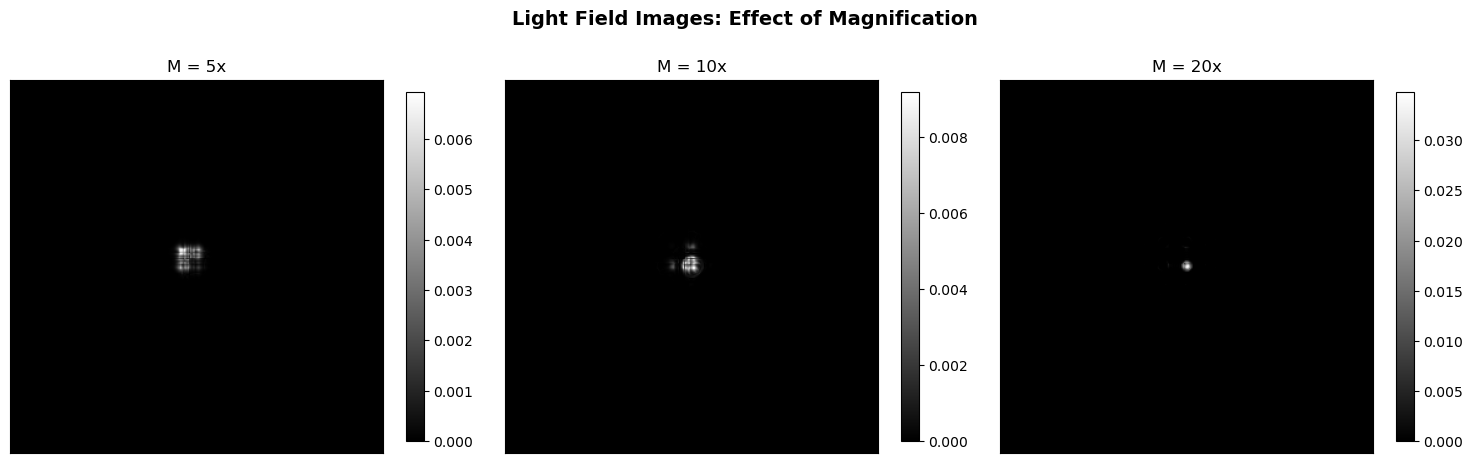

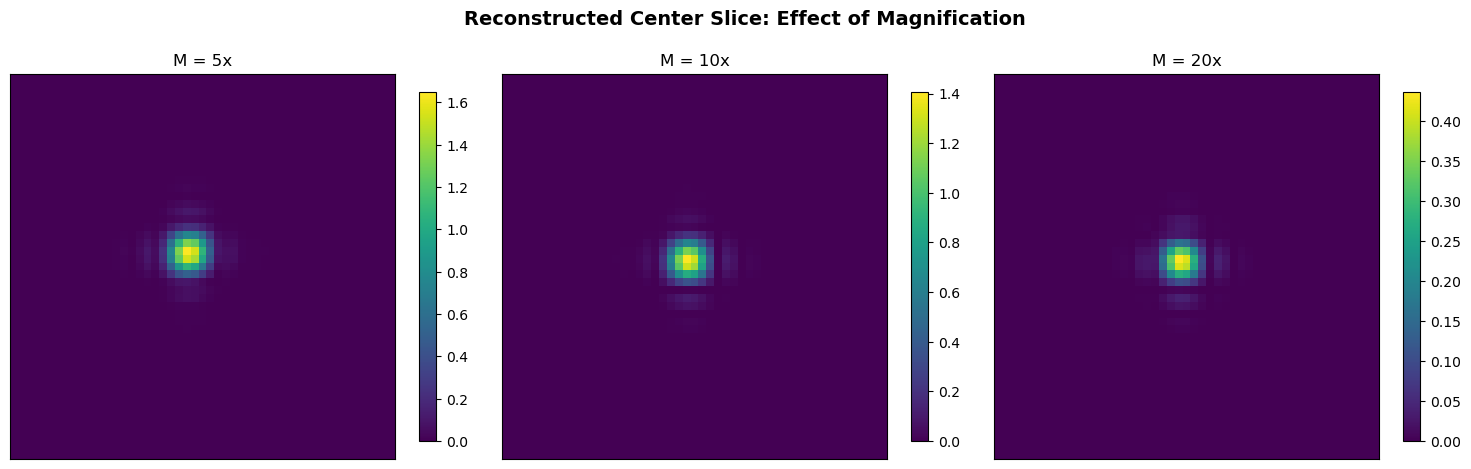

Higher magnification → specimen features are spread over more microlenses
→ more angular samples per feature → better reconstruction quality.


In [15]:
# Compare light field images
lf_images = [mag_results[m]['result']['lf_image'] for m in mag_values]
labels = [f'M = {m}x' for m in mag_values]
fig = compare_side_by_side(lf_images, labels,
                           suptitle="Light Field Images: Effect of Magnification")
plt.show()

# Compare reconstructed center slices
recon_slices = []
for m in mag_values:
    recon = mag_results[m]['result']['reconstructed']
    mid_z = recon.shape[2] // 2
    recon_slices.append(recon[:, :, mid_z])

fig = compare_side_by_side(recon_slices, labels, cmap='viridis',
                           suptitle="Reconstructed Center Slice: Effect of Magnification")
plt.show()

print("Higher magnification → specimen features are spread over more microlenses")
print("→ more angular samples per feature → better reconstruction quality.")

---
## Sandbox: Try Your Own Parameters

Use this cell to experiment with any configuration. Some ideas:

- Change `wavelength` (visible range: 0.4–0.7 um) — shorter wavelength = better diffraction limit
- Change `depth_range` and `depth_step` — more depth planes = finer axial sampling but slower
- Try `quality='medium'` for better results
- Combine misalignment types: shift + rotation
- Try different scenes: `create_planar_layer`, `create_tilted_plane`, `create_resolution_target`

=== LFM Configuration ===
  Objective: 10x / NA 0.3
  f_obj = 20000 um, f_tube = 200000 um
  Microlens: pitch=125 um, f=1875 um
  Sensor pixel: 6.5 um (19.2 px/lenslet)
  Wavelength: 0.525 um, n=1.0
  Depth range: [-300, 300] um, step=150 um
  Quality: 'fast'
Setting up camera parameters...
Computing geometry (simulation mode)...
[19 19] reg [6.578947368421052, 6.578947368421052] 56.25 [19 19]
[3 3] reg [  4.16666667   4.16666667 150.        ] 6.249999999999999 [3 3]
Super resolution factor of: [3 3]
Pix size: [6.578947368421052, 6.578947368421052]
Vox size: [4.166666666666666, 4.166666666666666, 150.0]
  Geometry ready in 0.2s
Computing PSF operators (this may take a while)...
Size of PSF radius ~= 10.0 [microlens pitch]
Size of PSF IMAGE = 381X381 [Pixels]
Computing PSF for main objective:
...
PSF: 1/5 in 2.87s
PSF: 2/5 in 2.91s
PSF: 3/5 in 2.92s
PSF: 4/5 already computed for depth -150.0
PSF: 5/5 already computed for depth -300.0
...
Computing forward patterns for single focus array

 forward patterns: 100%|████████████████| 5/5 [00:00<00:00,  7.00it/s]


Computing backward patterns for single focus array


backward patterns: 100%|██████████████| 10/10 [00:06<00:00,  1.58it/s]


  PSF operators ready in 16.2s
  Total setup time: 16.4s
  Volume shape: (49, 49, 5) (ny, nx, n_depths)
  Image shape: (301, 301)
  Depth planes: 5 from -300 to 300 um
Forward projecting...


...

Reconstructing...
Precomputing normalization projections...


backward: 100%|█████████████████████████| 5/5 [00:00<00:00, 18.52it/s]


  Iteration 1/1...


backward: 100%|█████████████████████████| 5/5 [00:00<00:00, 10.79it/s]


  Reconstruction done in 0.5s (1 iterations)


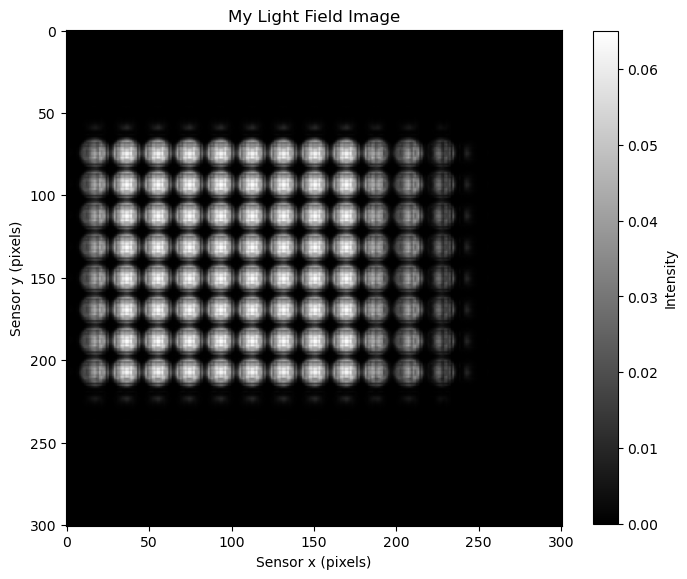

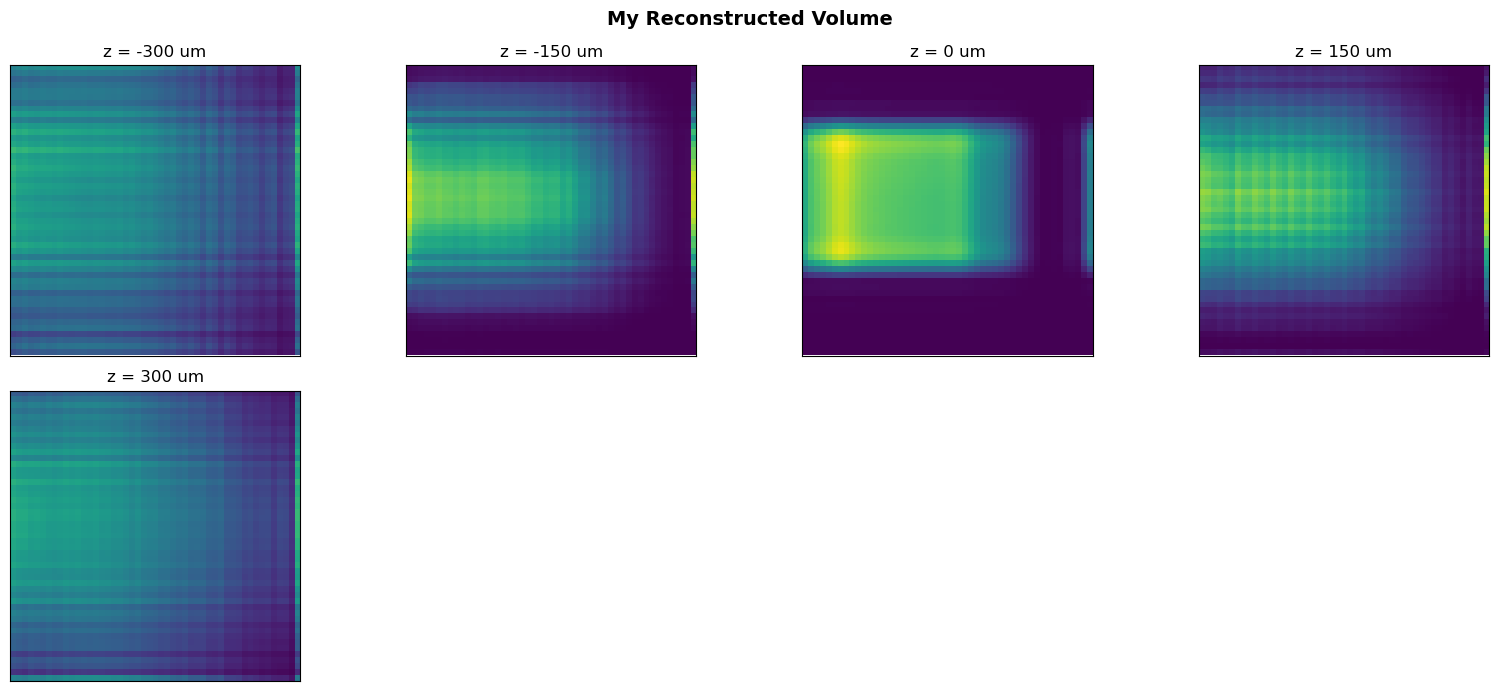

In [16]:
# === SANDBOX: Modify these parameters and re-run ===

my_config = LFMSimConfig(
    M=10,
    NA=0.3,
    fm=1875,            # microlens focal length (um)
    lens_pitch=125,     # microlens pitch (um)
    pixel_pitch=6.5,    # sensor pixel pitch (um)
    wavelength=0.525,   # emission wavelength (um)
    depth_range=(-300, 300),
    depth_step=150,
    quality='fast',     # 'fast', 'medium', or 'high'
)

my_config.summary()
my_sim = setup_simulation(my_config)

# Choose a scene:
# my_vol = create_point_sources(my_sim['volumeSize'], [(0.5, 0.5, 0.5)])
# my_vol = create_fluorescent_beads(my_sim['volumeSize'], [(0.3,0.5,0.3), (0.7,0.5,0.7)], bead_radius_voxels=3)
# my_vol = create_planar_layer(my_sim['volumeSize'], depth_frac=0.5, pattern='grid')
my_vol = create_resolution_target(my_sim['volumeSize'], depth_frac=0.5)

my_result = simulate_and_reconstruct(my_vol, my_sim)

fig = plot_light_field(my_result['lf_image'], title='My Light Field Image')
plt.show()

depths = get_depths_um(my_sim)
fig = plot_volume_slices(my_result['reconstructed'], depths_um=depths,
                         title='My Reconstructed Volume')
plt.show()